# Game of Life

### Description

[Game of Life](http://en.wikipedia.org/wiki/Conway's_Game_of_Life) (GoF) is a cellular automaton devised by the British mathematician John Horton Conway in 1970. The game is a zero-player game, meaning that its evolution is determined by its initial state, requiring no further input. One interacts with the Game of Life by creating an initial configuration and observing how it evolves, or, for advanced players, by creating patterns with particular properties.


The universe of the Game of Life is an infinite two-dimensional orthogonal grid of square cells, each of which is in one of two possible states, live or dead. Every cell interacts with its eight neighbours, which are the cells that are directly horizontally, vertically, or diagonally adjacent. At each step in time, the following transitions occur:

* Any live cell with fewer than two live neighbours dies, as if by needs caused by underpopulation.
* Any live cell with more than three live neighbours dies, as if by overcrowding.
* Any live cell with two or three live neighbours lives, unchanged, to the next generation.
* Any dead cell with exactly three live neighbours becomes a live cell.

The initial pattern constitutes the 'seed' of the system. The first generation is created by applying the above rules simultaneously to every cell in the seed – births and deaths happen simultaneously, and the discrete moment at which this happens is sometimes called a tick. (In other words, each generation is a pure function of the one before.) The rules continue to be applied repeatedly to create further generations.


### Assignments

Here follows project's assignments.

#### 1. Start off implementing the GoF's rules and play with simple seeds in small dimensions

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from pylab import imshow
from matplotlib.animation import FuncAnimation
%matplotlib notebook

In [17]:
def rule(grid):
    N, M = grid.shape
    new_grid = grid.copy()

    for x in range(1, N-1): # excluding boundaries
        for y in range(1, M-1): #excluding boundaries
            neighbors_alive = np.sum([grid[x+i, y+j]for i in [-1,0,1] for j in [-1,0,1] if not (i==0 and j==0)])

            if (grid[x,y] == 1):  # alive
                if ( (neighbors_alive < 2) or (neighbors_alive > 3) ): # under/over population
                    new_grid[x,y] = 0
                    
            else:  # death
                if (neighbors_alive == 3): # respawn
                    new_grid[x,y] = 1
    return new_grid

<IPython.core.display.Javascript object>


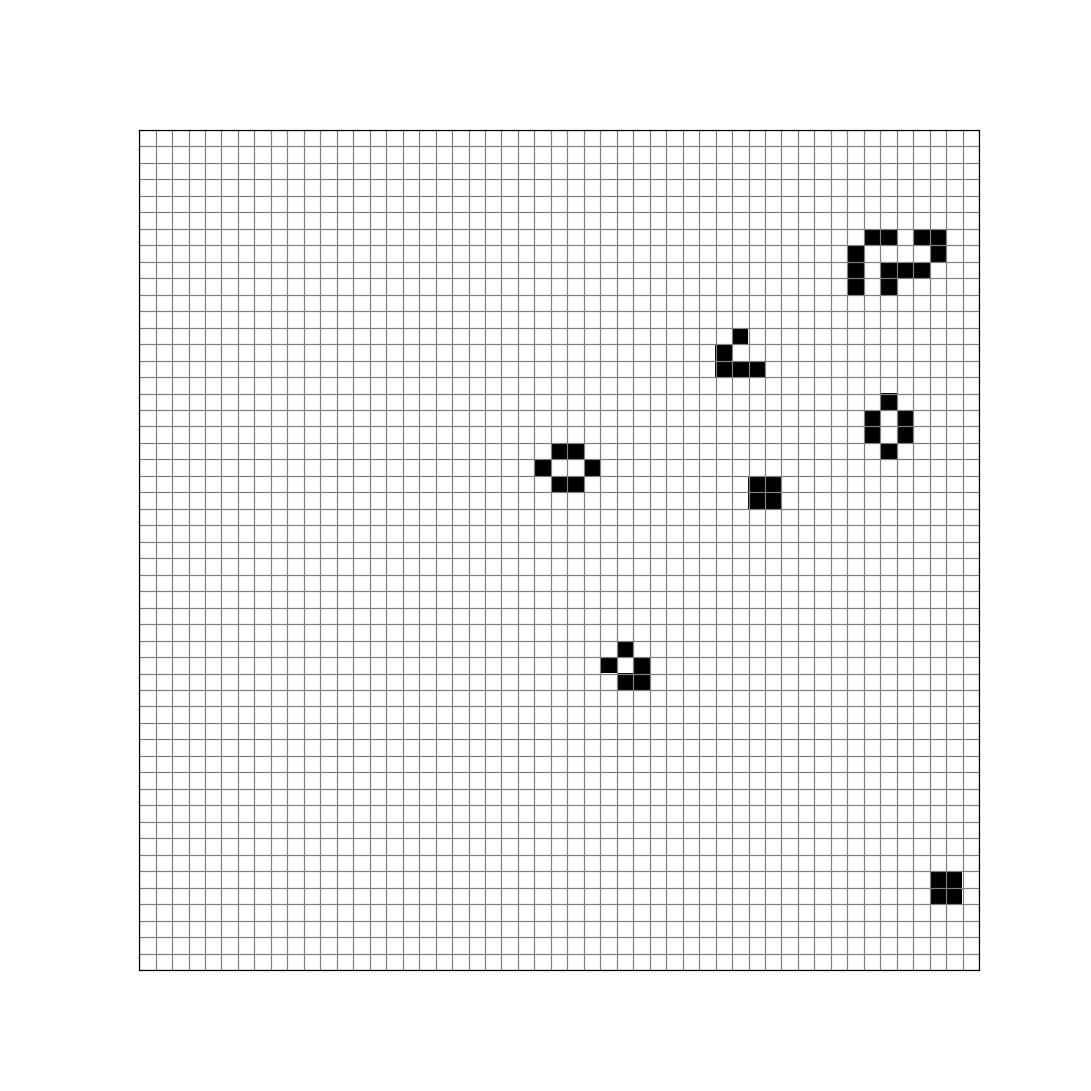

In [59]:
N = 50 + 1
epochs = 10
grid = np.zeros((N, N))
seed = np.array([[0, 0, 1, 1],  # R-pentomino kernel
                 [0, 1, 1, 0], 
                 [0, 1, 0, 0], 
                 [1, 1, 0, 0]])
x0, y0 = 25, 25
grid[x0:x0+seed.shape[0], y0:y0+seed.shape[1]] = seed

fig, ax = plt.subplots(figsize=(10,10)) #creo la figura (fig) el'area in cui disegnare(ax)
img = ax.imshow(grid, cmap='binary') #setto grid come disegno iniziale

#creo la griglia
ax.set_xticks(np.arange(-.5, N, 1), minor=False) 
ax.set_yticks(np.arange(-.5, N, 1), minor=False) #(-.5) sposta le righe tra le celle altrimenti le mette al centro della cella
ax.grid(which='both', color='gray', linestyle='-')

ax.tick_params(which='both', bottom=False, left=False,
               labelbottom=False, labelleft=False)

def update(frame):
    global grid #diciamo a python che è una variabile globale altrimenti non la trova
    grid = rule(grid) #applica le regole
    img.set_data(grid) #aggiorna i pixel con la nuova matrice (grid)
    return [img]

ani = FuncAnimation(fig, update, frames=epochs, interval=100)
plt.show()

<IPython.core.display.Javascript object>


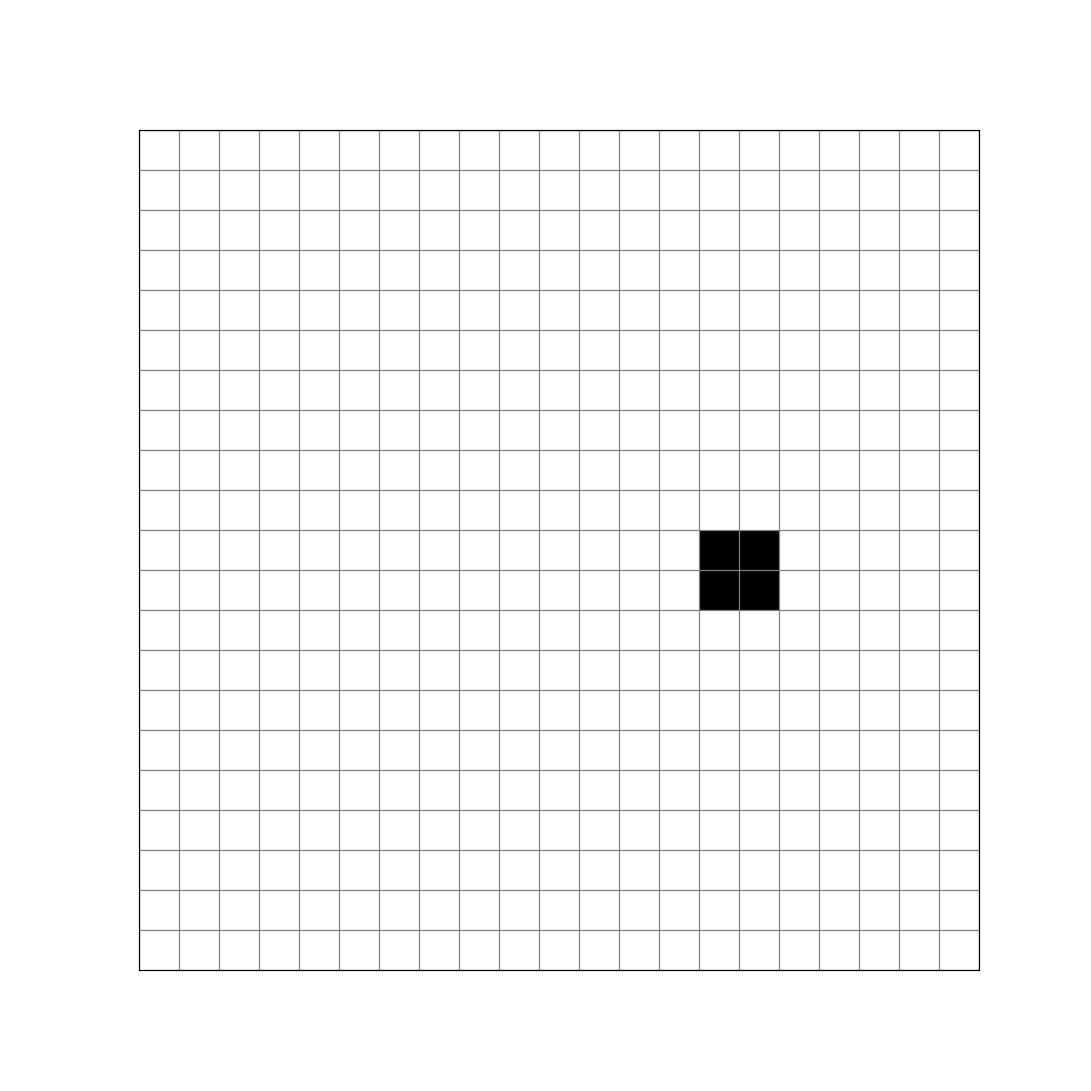

In [42]:
N = 20 + 1
epochs = 100
grid = np.zeros((N, N))
seed = np.array([[1, 1, 0, 0],  # R-pentomino kernel
                 [1, 1, 0, 0], 
                 [0, 1, 1, 0], 
                 [0, 0, 1, 1]])
x0, y0 = 10, 10
grid[x0:x0+seed.shape[0], y0:y0+seed.shape[1]] = seed

fig, ax = plt.subplots(figsize=(10,10)) #creo la figura (fig) el'area in cui disegnare(ax)
img = ax.imshow(grid, cmap='binary') #setto grid come disegno iniziale

#creo la griglia
ax.set_xticks(np.arange(-.5, N, 1), minor=False) 
ax.set_yticks(np.arange(-.5, N, 1), minor=False) #(-.5) sposta le righe tra le celle altrimenti le mette al centro della cella
ax.grid(which='both', color='gray', linestyle='-')

ax.tick_params(which='both', bottom=False, left=False,
               labelbottom=False, labelleft=False)

def update(frame):
    global grid #diciamo a python che è una variabile globale altrimenti non la trova
    grid = rule(grid) #applica le regole
    img.set_data(grid) #aggiorna i pixel con la nuova matrice (grid)
    return [img]

ani = FuncAnimation(fig, update, frames=epochs, interval=200)
plt.show()

#### 2. Increase the size of the GoF's world and play with more advanced pattern

#### 3. Implement examples of the three categories of patterns *still lifes*, *oscillators* and *spaceships*

#### 4. Analyse the evolutions of the patters in terms of frequency, replication, occupancy, etc.